# Зачет

Выполнил:  
Группа: ИД24-3    
Вариант: 

In [229]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn import datasets
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, precision_score, recall_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor

### 1.	Получить набор данных для анализа. Идентифицировать и описать задачу машинного обучения. Описать этот набор и решаемую задачу. Выделить целевую переменную и атрибуты.

In [232]:
a = datasets.load_diabetes()

In [234]:
print(a.DESCR)

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10 feature variables have bee

Задачи машинного обучения - регрессия, тк целевая переменная непрерывная (количественная мера заболевания). Мы предсказываем непрерывное число

In [237]:
df = pd.DataFrame(data = a.data, columns = a.feature_names)
df['target'] = a.target

In [239]:
df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [241]:
df.describe()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
count,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,442.000000
mean,-2.511817e-19,1.230790e-17,-2.245564e-16,-4.797570e-17,-1.381499e-17,3.918434e-17,-5.777179e-18,-9.042540e-18,9.293722e-17,1.130318e-17,152.133484
std,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,77.093005
min,-1.072256e-01,-4.464164e-02,-9.027530e-02,-1.123988e-01,-1.267807e-01,-1.156131e-01,-1.023071e-01,-7.639450e-02,-1.260971e-01,-1.377672e-01,25.000000
25%,-3.729927e-02,-4.464164e-02,-3.422907e-02,-3.665608e-02,-3.424784e-02,-3.035840e-02,-3.511716e-02,-3.949338e-02,-3.324559e-02,-3.317903e-02,87.000000
50%,5.383060e-03,-4.464164e-02,-7.283766e-03,-5.670422e-03,-4.320866e-03,-3.819065e-03,-6.584468e-03,-2.592262e-03,-1.947171e-03,-1.077698e-03,140.500000
75%,3.807591e-02,5.068012e-02,3.124802e-02,3.564379e-02,2.835801e-02,2.984439e-02,2.931150e-02,3.430886e-02,3.243232e-02,2.791705e-02,211.500000
max,1.107267e-01,5.068012e-02,1.705552e-01,1.320436e-01,1.539137e-01,1.987880e-01,1.811791e-01,1.852344e-01,1.335973e-01,1.356118e-01,346.000000


In [243]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
 10  target  442 non-null    float64
dtypes: float64(11)
memory usage: 38.1 KB


In [245]:
X = a.data
y = a.target

In [247]:
print(f'чисто строк(объектов): {X.shape[0]}')
print(f'число признаков(столбцов): {X.shape[1]}')

чисто строк(объектов): 442
число признаков(столбцов): 10


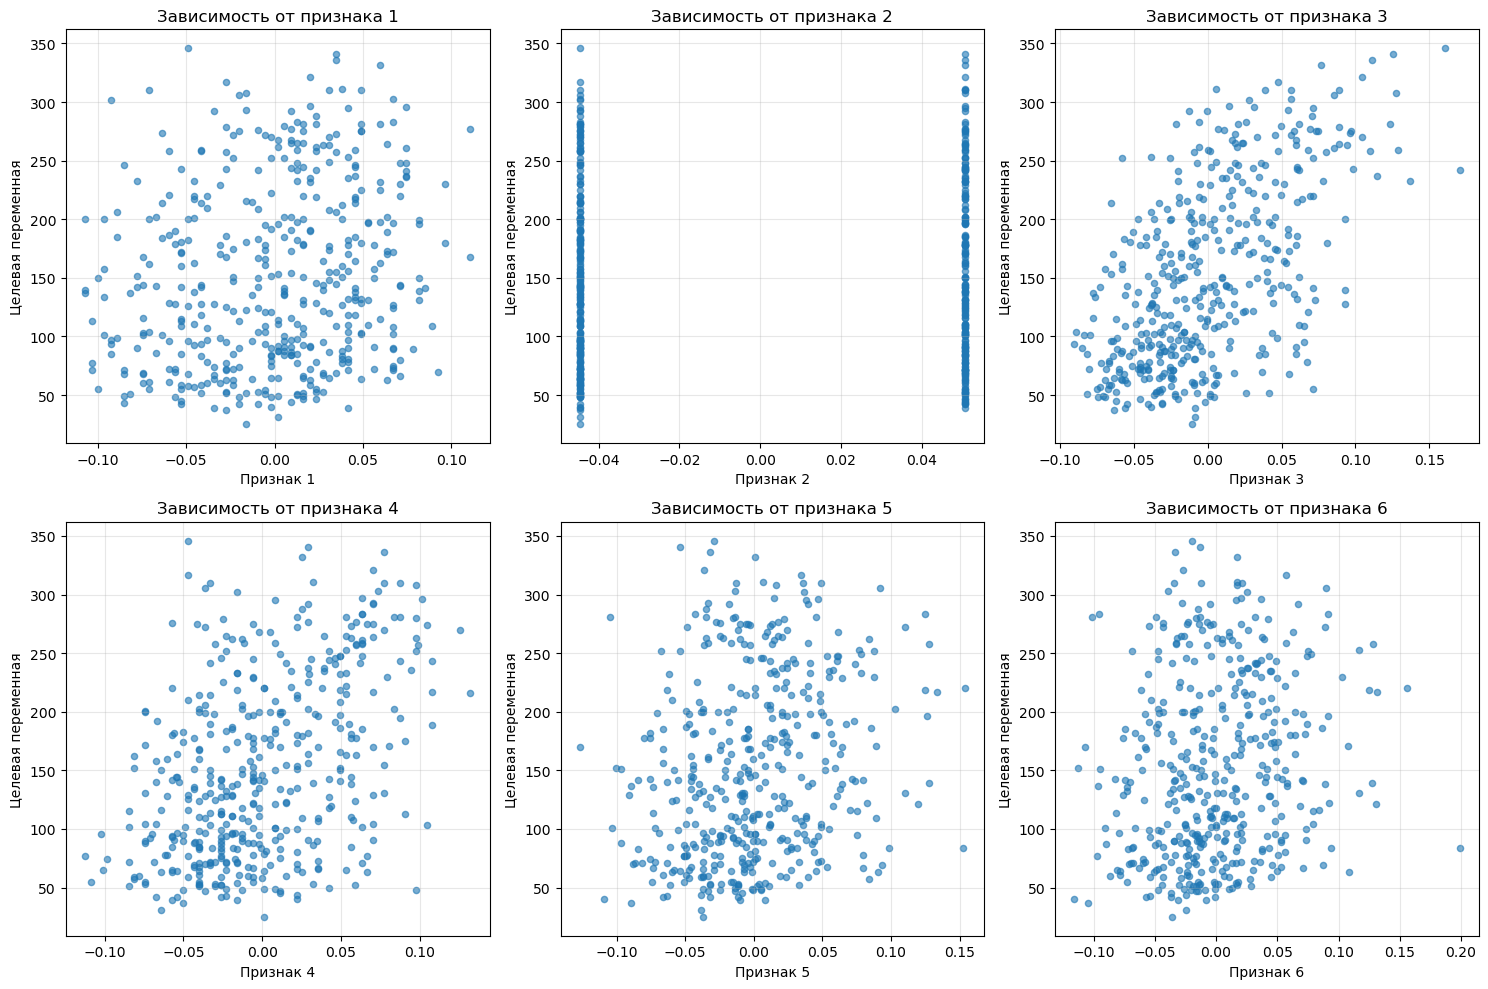

In [249]:
n_features = X.shape[1] if len(X.shape) > 1 else 1

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for i in range(min(n_features, 6)):
    if len(X.shape) > 1:
        axes[i].scatter(X[:, i], y, alpha=0.6, s=20)
        axes[i].set_xlabel(f'Признак {i+1}')
    else:
        axes[i].scatter(X, y, alpha=0.6, s=20)
        axes[i].set_xlabel('Признак')
    
    axes[i].set_ylabel('Целевая переменная')
    axes[i].set_title(f'Зависимость от признака {i+1}')
    axes[i].grid(True, alpha=0.3)

for i in range(n_features, 6):
    axes[i].axis('off')

plt.tight_layout()
plt.show()

### 2.	Разделить набор данных на обучающую и тестовую выборки.

In [252]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 42)

### 3.	Обучить несколько моделей для решения выбранной задачи (для задач классификации - не менее 7 различных алгоритмов (одну модель построите на двух факторных признаках), для задачи регрессии - не менее 5). Оценивается количество и разнообразие моделей.

In [255]:
scaler = StandardScaler()

In [257]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#### Линейная регрессия

In [260]:
lin_reg = LinearRegression()

In [262]:
lin_reg.fit(X_train_scaled, y_train)

LinearRegression()

In [264]:
y_pred_lin_reg = lin_reg.predict(X_test_scaled)

In [266]:
r2_lin_reg = r2_score(y_test, y_pred_lin_reg)
print(f'r2 score: {r2_lin_reg}')

r2 score: 0.4772897164322618


#### Дерево решений для регрессии

In [269]:
tree_reg = DecisionTreeRegressor(max_depth=5, random_state=42)

In [271]:
tree_reg.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=5, random_state=42)

In [273]:
y_pred_tree_reg = tree_reg.predict(X_test)

In [275]:
r2_tree_reg = r2_score(y_test, y_pred_tree_reg)
print(f'r2 score: {r2_tree_reg}')

r2 score: 0.2927280802447271


#### Метод опорных векторов для регрессии (SVR)

In [278]:
svr = SVR(kernel='rbf', C=1.0, epsilon=0.1)

In [280]:
svr.fit(X_train_scaled, y_train)

SVR()

In [282]:
y_pred_svr = svr.predict(X_test_scaled)

In [284]:
r2_svr = r2_score(y_test, y_pred_svr)
print(f'r2 score: {r2_svr}')

r2 score: 0.1611853727721696


#### K ближайших соседей для регрессии

In [287]:
knn_reg = KNeighborsRegressor(n_neighbors=5)

In [289]:
knn_reg.fit(X_train_scaled, y_train)

KNeighborsRegressor()

In [291]:
y_pred_knn_reg = knn_reg.predict(X_test_scaled)

In [293]:
r2_knn_reg = r2_score(y_test, y_pred_knn_reg)
print(f'r2 score: {r2_knn_reg}')

r2 score: 0.39282141984432284


#### MLP

In [296]:
mlp_reg = MLPRegressor(hidden_layer_sizes=(10,), max_iter=1000, random_state=42)

In [298]:
mlp_reg.fit(X_train_scaled, y_train)

C:\Users\Home\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPRegressor(hidden_layer_sizes=(10,), max_iter=1000, random_state=42)

In [299]:
y_pred_mlp_reg = mlp_reg.predict(X_test_scaled)

In [300]:
r2_mlp_reg = r2_score(y_test, y_pred_mlp_reg)
print(f'r2 score: {r2_mlp_reg}')

r2 score: -0.35735216470941045


### 4.	Оценить каждую из выбранных моделей по как можно большему количеству метрик эффективности. Для модели классификации, обученной на двух факторных признаков обязательно построить разделяющую поверхность. Для моделей регрессии - график зависимости теоретических значений от эмпирических.

#### LinearRegression

In [306]:
y_pred_lin_reg = lin_reg.predict(X_test_scaled)

In [308]:
print(f'r2 score: {r2_score(y_test, y_pred_lin_reg)}')
print(f'MAE: {mean_absolute_error(y_test, y_pred_lin_reg)}')
print(f'MSE: {mean_squared_error(y_test, y_pred_lin_reg)}')
print(f'RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_lin_reg))}')

r2 score: 0.4772897164322618
MAE: 41.91937845679273
MSE: 2821.7509810013103
RMSE: 53.1201560709427


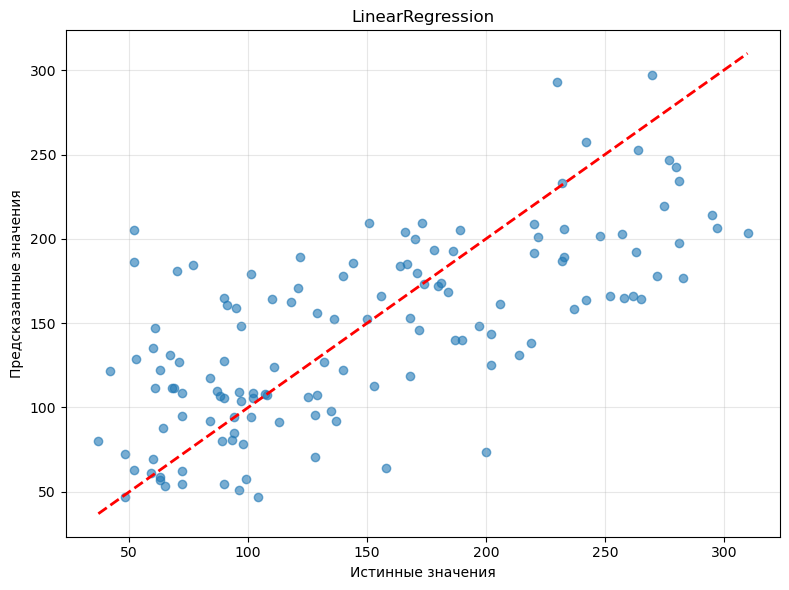

In [310]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_lin_reg, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Истинные значения')
plt.ylabel('Предсказанные значения')
plt.title('LinearRegression')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#### DecisionTreeRegressor

In [313]:
y_pred_tree_reg = tree_reg.predict(X_test)

In [315]:
print(f'r2 score: {r2_score(y_test, y_pred_tree_reg)}')
print(f'MAE: {mean_absolute_error(y_test, y_pred_tree_reg)}')
print(f'MSE: {mean_squared_error(y_test, y_pred_tree_reg)}')
print(f'RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_tree_reg))}')

r2 score: 0.2927280802447271
MAE: 48.56933581075364
MSE: 3818.0714941788437
RMSE: 61.79054534618418


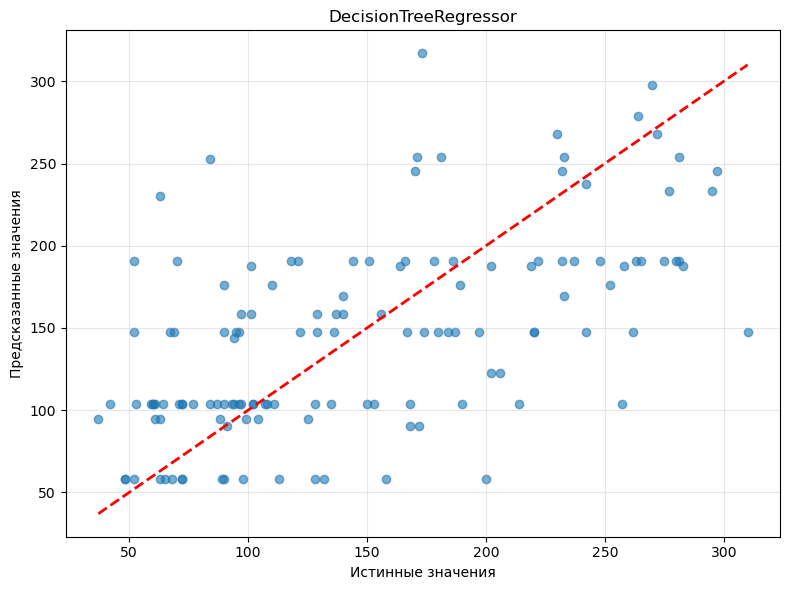

In [317]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_tree_reg, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Истинные значения')
plt.ylabel('Предсказанные значения')
plt.title('DecisionTreeRegressor')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#### SVR

In [320]:
y_pred_svr = svr.predict(X_test_scaled)

In [322]:
print(f'r2 score: {r2_score(y_test, y_pred_svr)}')
print(f'MAE: {mean_absolute_error(y_test, y_pred_svr)}')
print(f'MSE: {mean_squared_error(y_test, y_pred_svr)}')
print(f'RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_svr))}')

r2 score: 0.1611853727721696
MAE: 56.43424404556508
MSE: 4528.179512947439
RMSE: 67.29174921896026


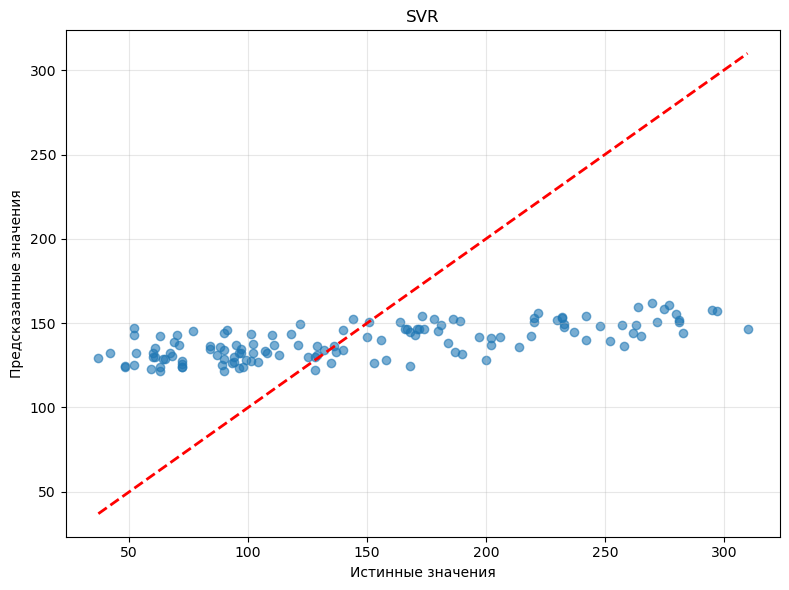

In [324]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_svr, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Истинные значения')
plt.ylabel('Предсказанные значения')
plt.title('SVR')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#### KNeighborsRegressor

In [327]:
y_pred_knn_reg = knn_reg.predict(X_test_scaled)

In [329]:
print(f'r2 score: {r2_score(y_test, y_pred_knn_reg)}')
print(f'MAE: {mean_absolute_error(y_test, y_pred_knn_reg)}')
print(f'MSE: {mean_squared_error(y_test, y_pred_knn_reg)}')
print(f'RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_knn_reg))}')

r2 score: 0.39282141984432284
MAE: 44.80451127819549
MSE: 3277.7368421052633
RMSE: 57.251522618226176


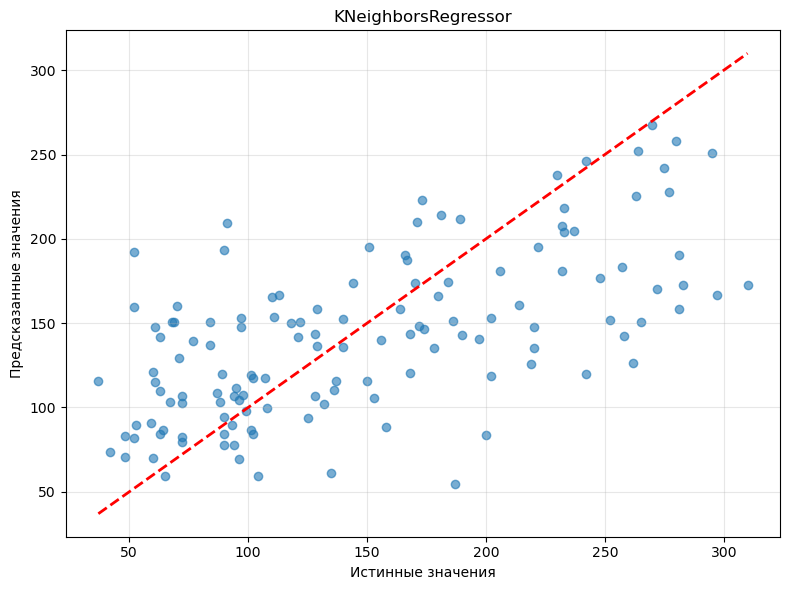

In [331]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_knn_reg, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Истинные значения')
plt.ylabel('Предсказанные значения')
plt.title('KNeighborsRegressor')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#### MLPRegressor

In [334]:
y_pred_mlp_reg = mlp_reg.predict(X_test_scaled)

In [336]:
print(f'r2 score: {r2_score(y_test, y_pred_mlp_reg)}')
print(f'MAE: {mean_absolute_error(y_test, y_pred_mlp_reg)}')
print(f'MSE: {mean_squared_error(y_test, y_pred_mlp_reg)}')
print(f'RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_mlp_reg))}')

r2 score: -0.35735216470941045
MAE: 66.06405384026395
MSE: 7327.404726363464
RMSE: 85.60026125172436


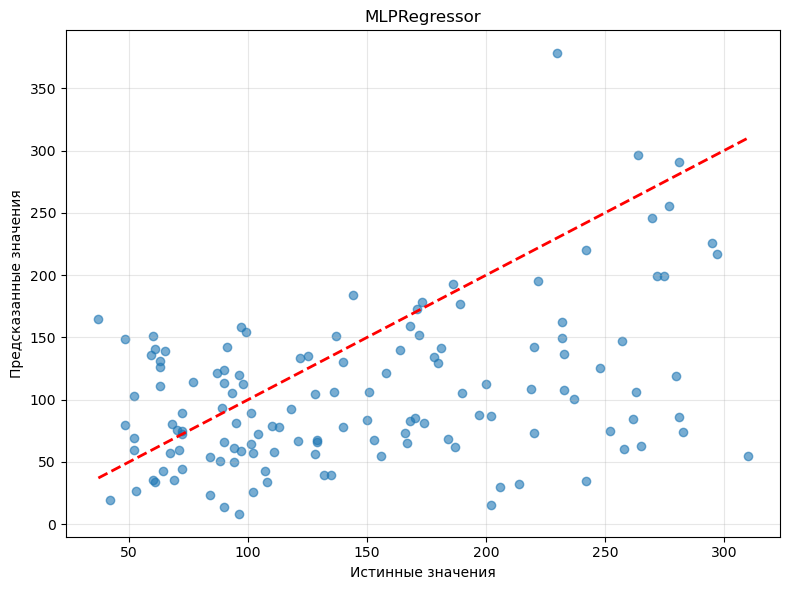

In [338]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_mlp_reg, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Истинные значения')
plt.ylabel('Предсказанные значения')
plt.title('MLPRegressor')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 5.	Оценка моделей должно проводиться на тестовой выборке. Для каждой модели нужно проанализировать эффективность на обучающей выборке справочно.

In [341]:
def calculate_metrics(model_name, y_true, y_pred, y_train_true=None, y_train_pred=None):
    metrics = {
        'model': model_name,
        'test_r2': r2_score(y_true, y_pred),
        'test_mae': mean_absolute_error(y_true, y_pred),
        'test_mse': mean_squared_error(y_true, y_pred),
        'test_rmse': np.sqrt(mean_squared_error(y_true, y_pred)),
    }

    if y_train_true is not None and y_train_pred is not None:
        metrics['train_r2'] = r2_score(y_train_true, y_train_pred)
        metrics['train_rmse'] = np.sqrt(mean_squared_error(y_train_true, y_train_pred))
        metrics['r2_diff'] = metrics['train_r2'] - metrics['test_r2']

    return metrics

In [343]:
all_metrics = []
models_info = [
    ('Линейная регрессия', y_test, y_pred_lin_reg, y_train, lin_reg.predict(X_train_scaled)),
    ('K-ближайших соседей knn', y_test, y_pred_knn_reg, y_train, knn_reg.predict(X_train_scaled)),
    ('Дерево решений', y_test, y_pred_tree_reg, y_train, tree_reg.predict(X_train)),
    ('Метод опорных векторов SVR', y_test, y_pred_svr, y_train, svr.predict(X_train_scaled)),
    ('Нейронная сеть MLP', y_test, y_pred_mlp_reg, y_train, mlp_reg.predict(X_train_scaled))]

for model_name, y_test_vals, y_pred, y_train_vals, y_train_pred in models_info:
    metrics = calculate_metrics(model_name, y_test_vals, y_pred, y_train_vals, y_train_pred)
    all_metrics.append(metrics)

In [345]:
results_df = pd.DataFrame(all_metrics)

### 6.	Составить итоговую таблицу эффективности моделей, в которую свести все численные метрики. Сделать вывод о применимости моделей для решения конкретной поставленной задачи.

In [348]:
results_df

,model,test_r2,test_mae,test_mse,test_rmse,train_r2,train_rmse,r2_diff
0,Линейная регрессия,0.477290,41.919378,2821.750981,53.120156,0.524412,54.074452,0.047123
1,K-ближайших соседей knn,0.392821,44.804511,3277.736842,57.251523,0.572950,51.240840,0.180129
2,Дерево решений,0.292728,48.569336,3818.071494,61.790545,0.680282,44.336431,0.387553
3,Метод опорных векторов SVR,0.161185,56.434244,4528.179513,67.291749,0.141661,72.645104,-0.019525
4,Нейронная сеть MLP,-0.357352,66.064054,7327.404726,85.600261,-0.180344,85.188547,0.177008


Лучшая модель по r2 на тестовой выборке - Линейная регрессия (r2 = 0.477). K-ближайших соседей knn (r2 = 0.393). Дерево решений показало удовлетворительный результат (r2 = 0.293). Метод опорных векторов SVR работает плохо (R² = 0.161). MLP показала отрицательный r2 (-0.357), что означает, что она работает хуже простого предсказания средним значением и категорически не рекомендуется для данной задачи регрессии.